This notebook visualizes predator–prey policy interactions using behavioral cloning under various speed conditions for 16-prey and 32-prey scenarios.

### Visualize BC

In [36]:
# set working directory
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

import numpy as np
print(np.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.2.6


In [37]:
import torch
from pathlib import Path
from datetime import datetime

# project specific helper modules
from utils.sim_utils import *
from utils.train_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *

from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator

In [38]:
!apt-get install -y ffmpeg -qq

In [39]:
from pathlib import Path
import torch

# create the model structures
prey_policy = ModularPolicy(features=6).to(device)
pred_policy = ModularPolicy(features=5).to(device)

# paths to saved weights
prey_path = Path("/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_prey_policy.pt")
pred_path = Path("/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_pred_policy.pt")

# load learned weights
prey_policy.load_state_dict(torch.load(prey_path, map_location=device, weights_only=True))
pred_policy.load_state_dict(torch.load(pred_path, map_location=device, weights_only=True))

# evaluation mode
prey_policy.eval()
pred_policy.eval()

print("Policies loaded successfully.")

Policies loaded successfully.


16 Prey Condition:

In [40]:
# load init pool
init_pool_path = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_16prey.pt')
init_pool = torch.load(init_pool_path).to(device)

In [41]:
%matplotlib inline
# run a simulation with the pretrained policies
gen_pred_tensor, gen_prey_tensor, metrics = run_env_simulation(visualization='off',
                                                      prey_policy=prey_policy, pred_policy=pred_policy,
                                                      n_prey=16, n_pred=1,
                                                      pred_speed=10, prey_speed=10,
                                                      max_speed_norm=25,
                                                      max_steps=100, step_size=1,
                                                      area_width=2160, area_height=2160,
                                                      max_turn=0.314,
                                                      init_pool=init_pool)
metrics_list, weights_list = metrics

In [42]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 2160)
ax.set_ylim(0, 2160)
ax.set_aspect("equal")

pred_scat = ax.scatter([], [], c="red", s=60, label="Predator")
prey_scat = ax.scatter([], [], c="blue", s=20, label="Prey")
ax.legend()

def update(frame):
    m = metrics_list[frame]

    xs = np.asarray(m["xs"]) * 2160
    ys = np.asarray(m["ys"]) * 2160

    pred_scat.set_offsets([[xs[0], ys[0]]])
    prey_scat.set_offsets(np.column_stack([xs[1:], ys[1:]]))

    ax.set_title(f"16 prey — step {frame}")
    return pred_scat, prey_scat

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(metrics_list),
    interval=1000 / 15,
    blit=True
)

out_path = "/content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_16prey.mp4"

ani.save(
    out_path,
    writer=animation.FFMpegWriter(fps=15, bitrate=1800)
)

plt.close(fig)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_16prey.mp4


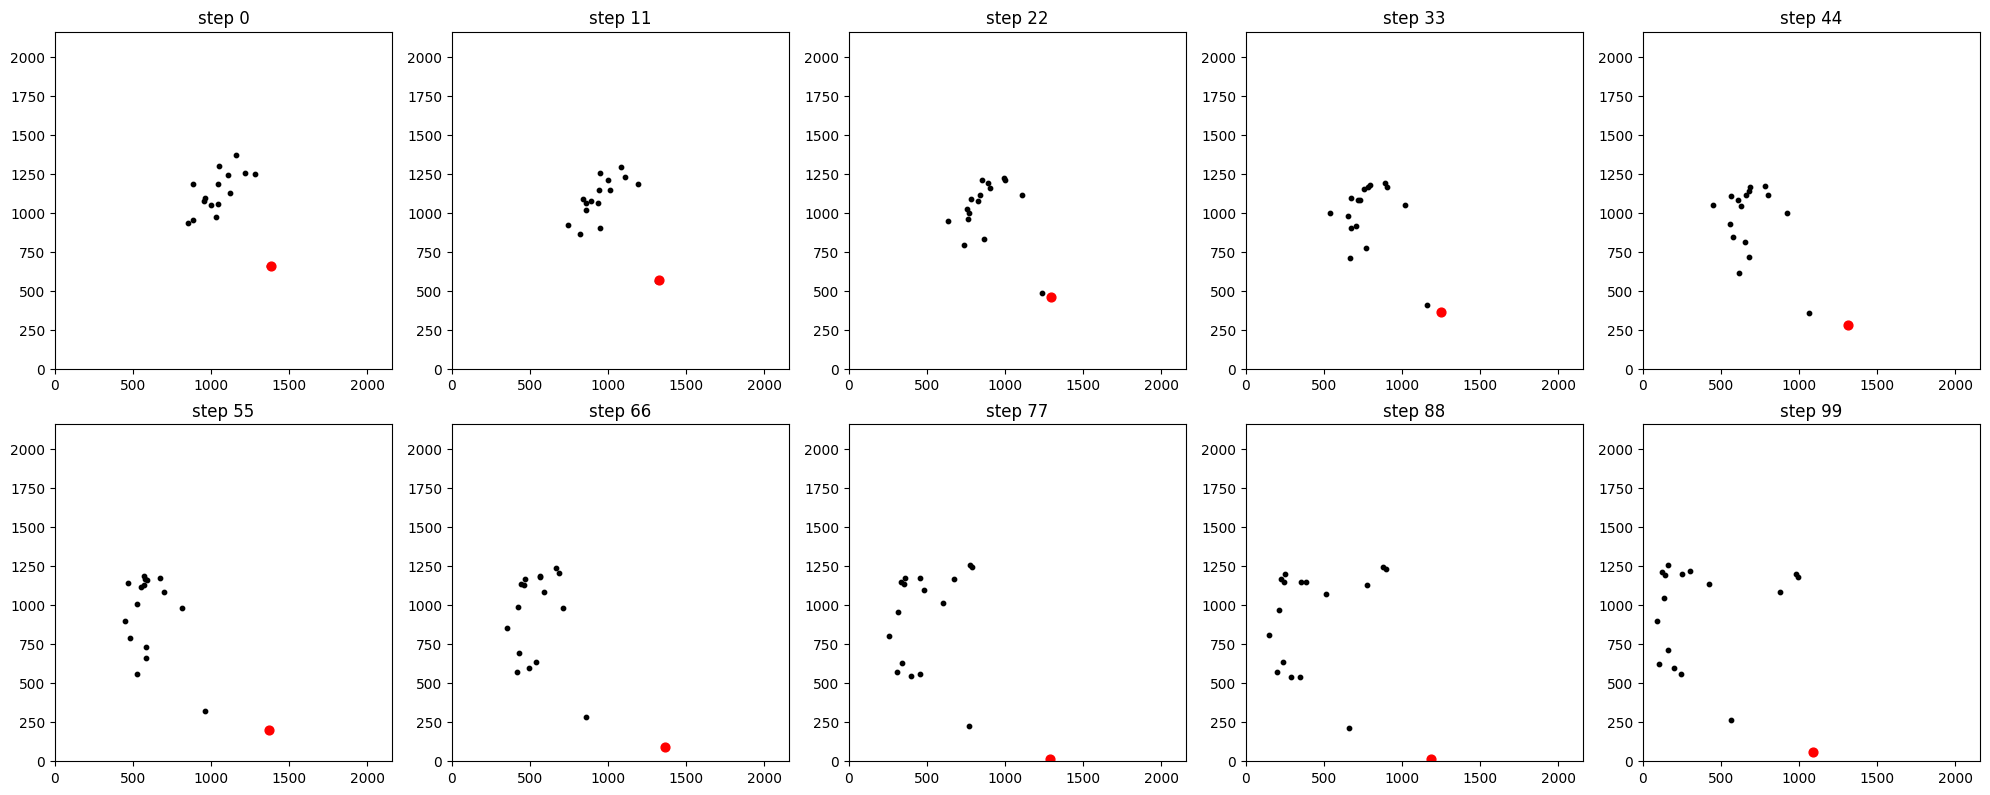

In [43]:
metrics_list, weights_list = metrics

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = np.linspace(0, len(metrics_list) - 1, 10, dtype=int)

for ax, step in zip(axes.flat, steps_to_show):
    m = metrics_list[step]
    xs, ys = m["xs"] * 2160, m["ys"] * 2160  # unscale back to pixel coords (area_width/height)
    ax.scatter(xs[1:], ys[1:], c='black', s=10, label='prey')
    ax.scatter(xs[0], ys[0], c='red', s=40, label='predator')
    ax.set_xlim(0, 2160); ax.set_ylim(0, 2160)
    ax.set_aspect('equal')
    ax.set_title(f"step {step}")
plt.tight_layout()
plt.show()

32 Prey Condition:

In [44]:
init_pool_32_path = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_32prey.pt')
init_pool_32 = torch.load(init_pool_32_path).to(device)

In [45]:
%matplotlib inline
# run a simulation with the pretrained policies — 32-prey condition
gen_pred_tensor_32, gen_prey_tensor_32, metrics_32 = run_env_simulation(visualization='off',
                                                      prey_policy=prey_policy, pred_policy=pred_policy,
                                                      n_prey=32, n_pred=1,
                                                      pred_speed=10, prey_speed=10,
                                                      max_speed_norm=25,
                                                      max_steps=100, step_size=1,
                                                      area_width=2160, area_height=2160,
                                                      max_turn=0.314,
                                                      init_pool=init_pool_32)
metrics_list_32, weights_list_32 = metrics_32

In [46]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 2160)
ax.set_ylim(0, 2160)
ax.set_aspect("equal")

pred_scat = ax.scatter([], [], c="red", s=60, label="Predator")
prey_scat = ax.scatter([], [], c="blue", s=20, label="Prey")
ax.legend()

def update(frame):
    m = metrics_list_32[frame]

    xs = np.asarray(m["xs"]) * 2160
    ys = np.asarray(m["ys"]) * 2160

    pred_scat.set_offsets([[xs[0], ys[0]]])
    prey_scat.set_offsets(np.column_stack([xs[1:], ys[1:]]))

    ax.set_title(f"32 prey — step {frame}")
    return pred_scat, prey_scat

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(metrics_list_32),
    interval=1000 / 15,
    blit=True
)

out_path_32 = "/content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_32prey.mp4"

ani.save(
    out_path_32,
    writer=animation.FFMpegWriter(fps=15, bitrate=1800)
)

plt.close(fig)
print("Saved:", out_path_32)

Saved: /content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_32prey.mp4


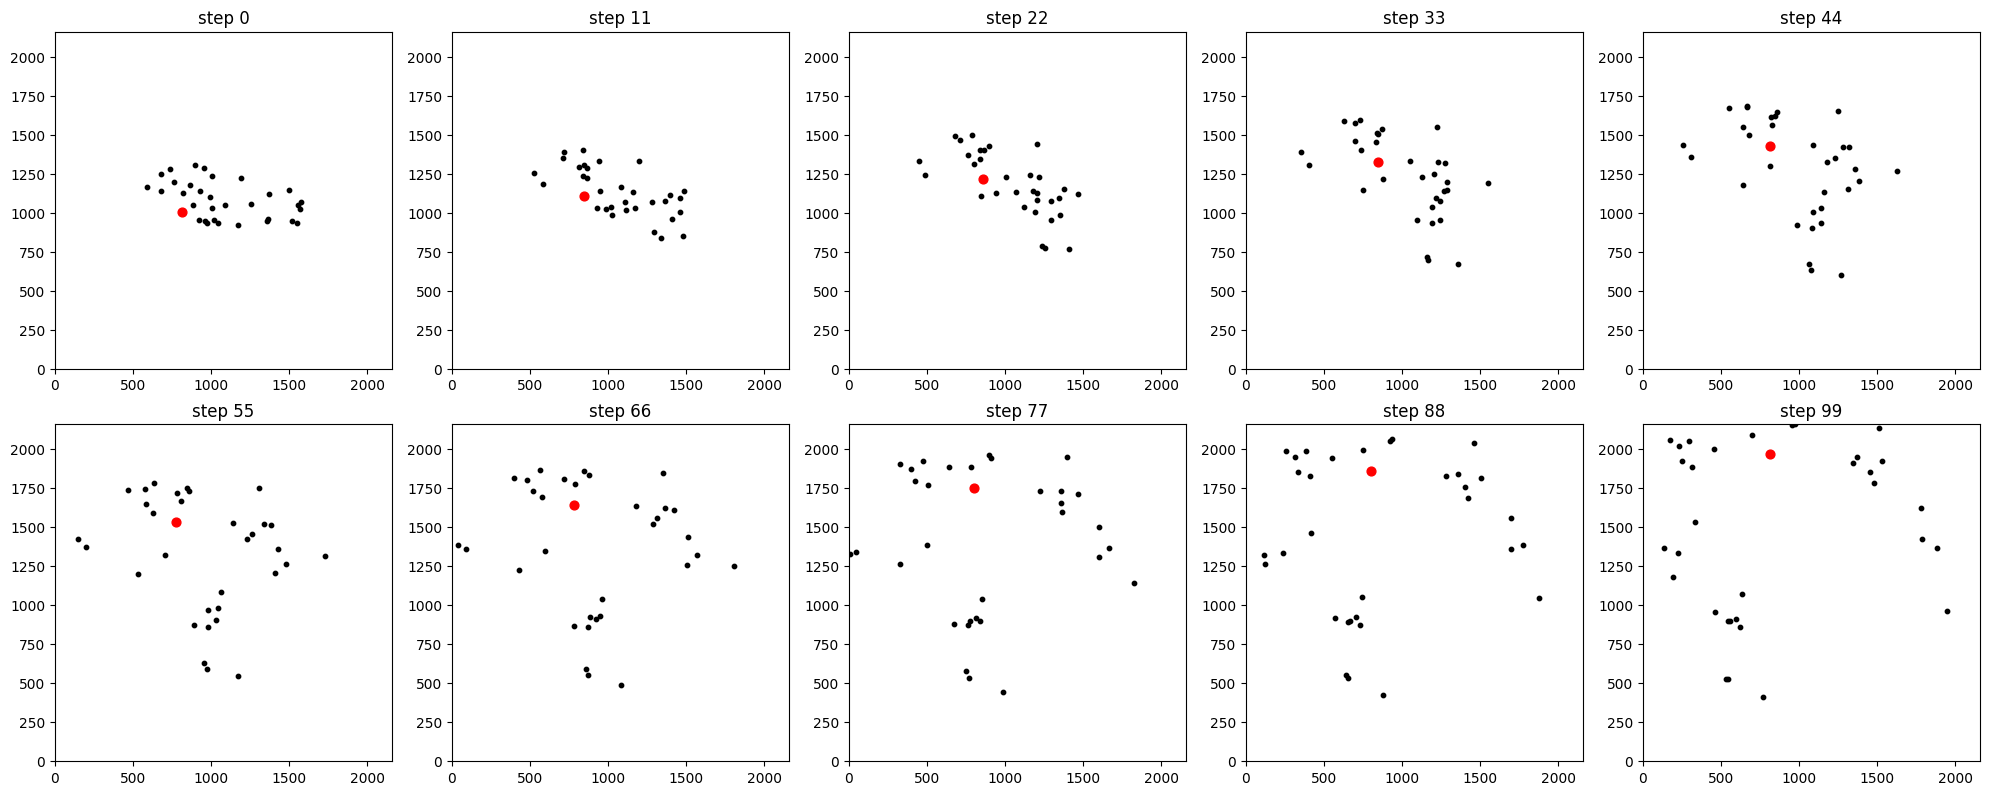

In [47]:
metrics_list_32, weights_list_32 = metrics_32
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = np.linspace(0, len(metrics_list_32) - 1, 10, dtype=int)
for ax, step in zip(axes.flat, steps_to_show):
    m = metrics_list_32[step]
    xs, ys = m["xs"] * 2160, m["ys"] * 2160
    ax.scatter(xs[1:], ys[1:], c='black', s=10, label='prey')
    ax.scatter(xs[0], ys[0], c='red', s=40, label='predator')
    ax.set_xlim(0, 2160); ax.set_ylim(0, 2160)
    ax.set_aspect('equal')
    ax.set_title(f"step {step}")
plt.tight_layout()
plt.show()

### Visualize BC (faster pred)

In [16]:
!apt-get install -y ffmpeg -qq

In [17]:
from pathlib import Path
import torch

# create the model structures
prey_policy = ModularPolicy(features=6).to(device)
pred_policy = ModularPolicy(features=5).to(device)

# paths to saved weights
prey_path = Path("/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_prey_policy.pt")
pred_path = Path("/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_pred_policy.pt")

# load learned weights
prey_policy.load_state_dict(torch.load(prey_path, map_location=device, weights_only=True))
pred_policy.load_state_dict(torch.load(pred_path, map_location=device, weights_only=True))

# evaluation mode
prey_policy.eval()
pred_policy.eval()

print("Policies loaded successfully.")

Policies loaded successfully.


16 Prey Condition:

In [18]:
# load init pool
init_pool_path = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_16prey.pt')
init_pool = torch.load(init_pool_path).to(device)

In [19]:
%matplotlib inline
# run a simulation with the pretrained policies
gen_pred_tensor, gen_prey_tensor, metrics = run_env_simulation(visualization='off',
                                                      prey_policy=prey_policy, pred_policy=pred_policy,
                                                      n_prey=16, n_pred=1,
                                                      pred_speed=12, prey_speed=8,
                                                      max_speed_norm=25,
                                                      max_steps=100, step_size=1,
                                                      area_width=2160, area_height=2160,
                                                      max_turn=0.314,
                                                      init_pool=init_pool)
metrics_list, weights_list = metrics

In [20]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 2160)
ax.set_ylim(0, 2160)
ax.set_aspect("equal")

pred_scat = ax.scatter([], [], c="red", s=60, label="Predator")
prey_scat = ax.scatter([], [], c="blue", s=20, label="Prey")
ax.legend()

def update(frame):
    m = metrics_list[frame]

    xs = np.asarray(m["xs"]) * 2160
    ys = np.asarray(m["ys"]) * 2160

    pred_scat.set_offsets([[xs[0], ys[0]]])
    prey_scat.set_offsets(np.column_stack([xs[1:], ys[1:]]))

    ax.set_title(f"16 prey — step {frame}")
    return pred_scat, prey_scat

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(metrics_list),
    interval=1000 / 15,
    blit=True
)

out_path = "/content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_16prey_fasterpred.mp4"

ani.save(
    out_path,
    writer=animation.FFMpegWriter(fps=15, bitrate=1800)
)

plt.close(fig)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_16prey_fasterpred.mp4


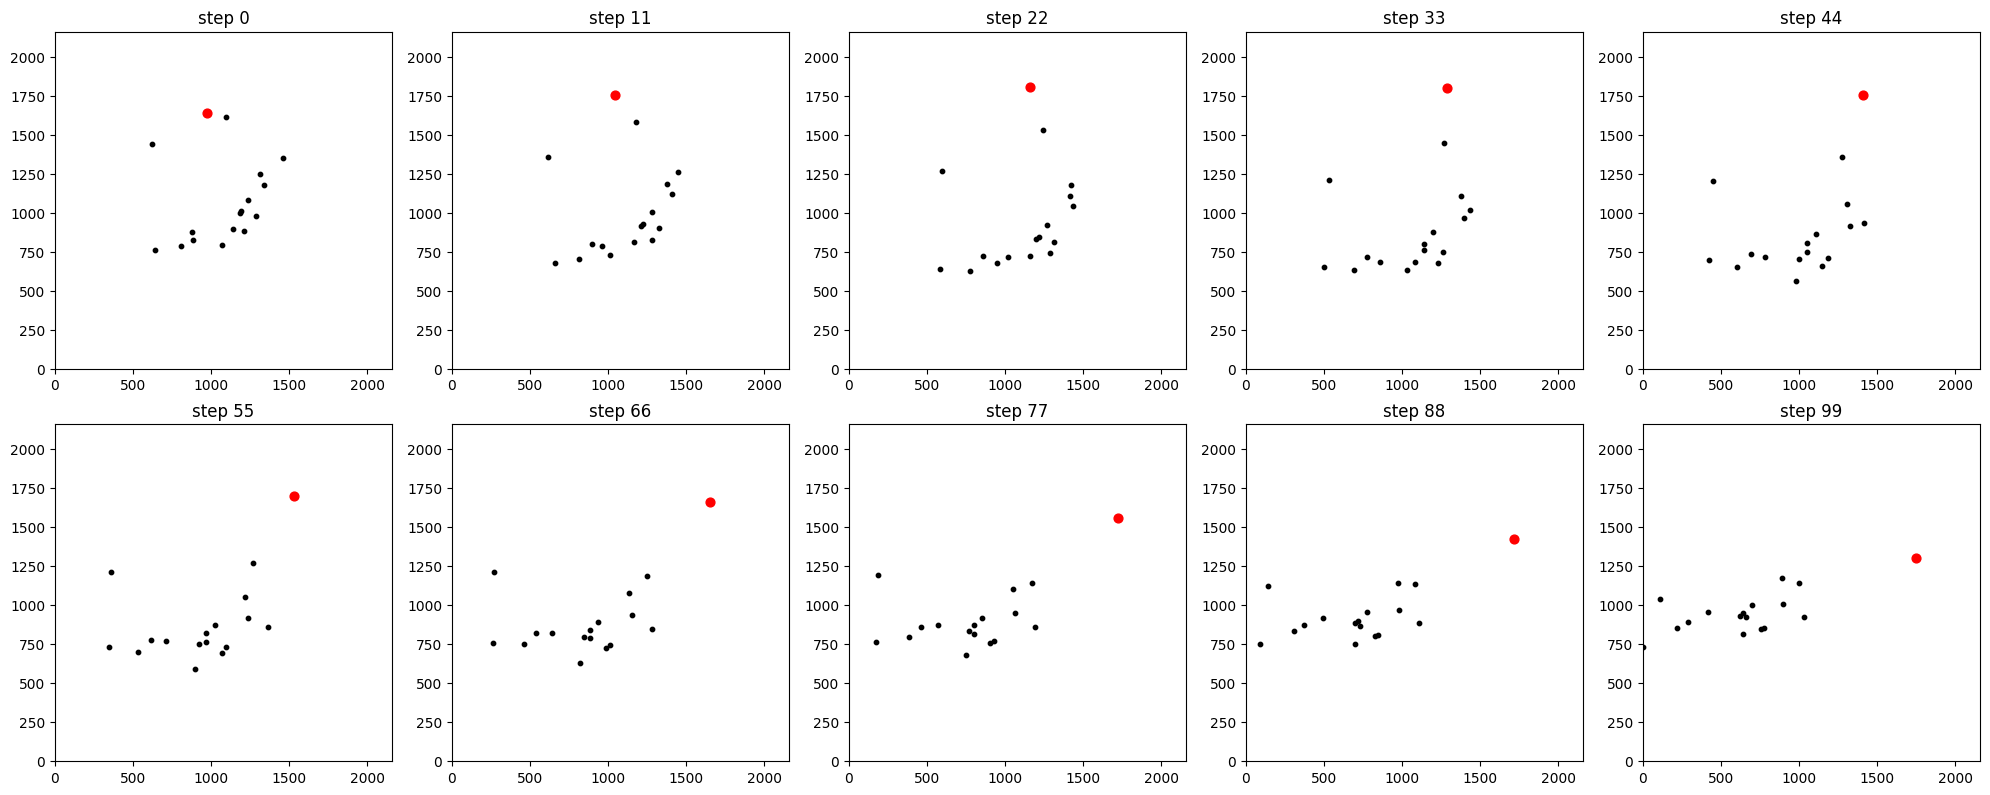

In [21]:
metrics_list, weights_list = metrics

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = np.linspace(0, len(metrics_list) - 1, 10, dtype=int)

for ax, step in zip(axes.flat, steps_to_show):
    m = metrics_list[step]
    xs, ys = m["xs"] * 2160, m["ys"] * 2160  # unscale back to pixel coords (area_width/height)
    ax.scatter(xs[1:], ys[1:], c='black', s=10, label='prey')
    ax.scatter(xs[0], ys[0], c='red', s=40, label='predator')
    ax.set_xlim(0, 2160); ax.set_ylim(0, 2160)
    ax.set_aspect('equal')
    ax.set_title(f"step {step}")
plt.tight_layout()
plt.show()

32 Prey Condition:

In [22]:
init_pool_32_path = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_32prey.pt')
init_pool_32 = torch.load(init_pool_32_path).to(device)

In [23]:
%matplotlib inline
# run a simulation with the pretrained policies — 32-prey condition
gen_pred_tensor_32, gen_prey_tensor_32, metrics_32 = run_env_simulation(visualization='off',
                                                      prey_policy=prey_policy, pred_policy=pred_policy,
                                                      n_prey=32, n_pred=1,
                                                      pred_speed=12, prey_speed=8,
                                                      max_speed_norm=25,
                                                      max_steps=100, step_size=1,
                                                      area_width=2160, area_height=2160,
                                                      max_turn=0.314,
                                                      init_pool=init_pool_32)
metrics_list_32, weights_list_32 = metrics_32

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 2160)
ax.set_ylim(0, 2160)
ax.set_aspect("equal")

pred_scat = ax.scatter([], [], c="red", s=60, label="Predator")
prey_scat = ax.scatter([], [], c="blue", s=20, label="Prey")
ax.legend()

def update(frame):
    m = metrics_list_32[frame]

    xs = np.asarray(m["xs"]) * 2160
    ys = np.asarray(m["ys"]) * 2160

    pred_scat.set_offsets([[xs[0], ys[0]]])
    prey_scat.set_offsets(np.column_stack([xs[1:], ys[1:]]))

    ax.set_title(f"32 prey — step {frame}")
    return pred_scat, prey_scat

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(metrics_list_32),
    interval=1000 / 15,
    blit=True
)

out_path_32 = "/content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_32prey_fasterpred.mp4"

ani.save(
    out_path_32,
    writer=animation.FFMpegWriter(fps=15, bitrate=1800)
)

plt.close(fig)
print("Saved:", out_path_32)

Saved: /content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_32prey_fasterpred.mp4


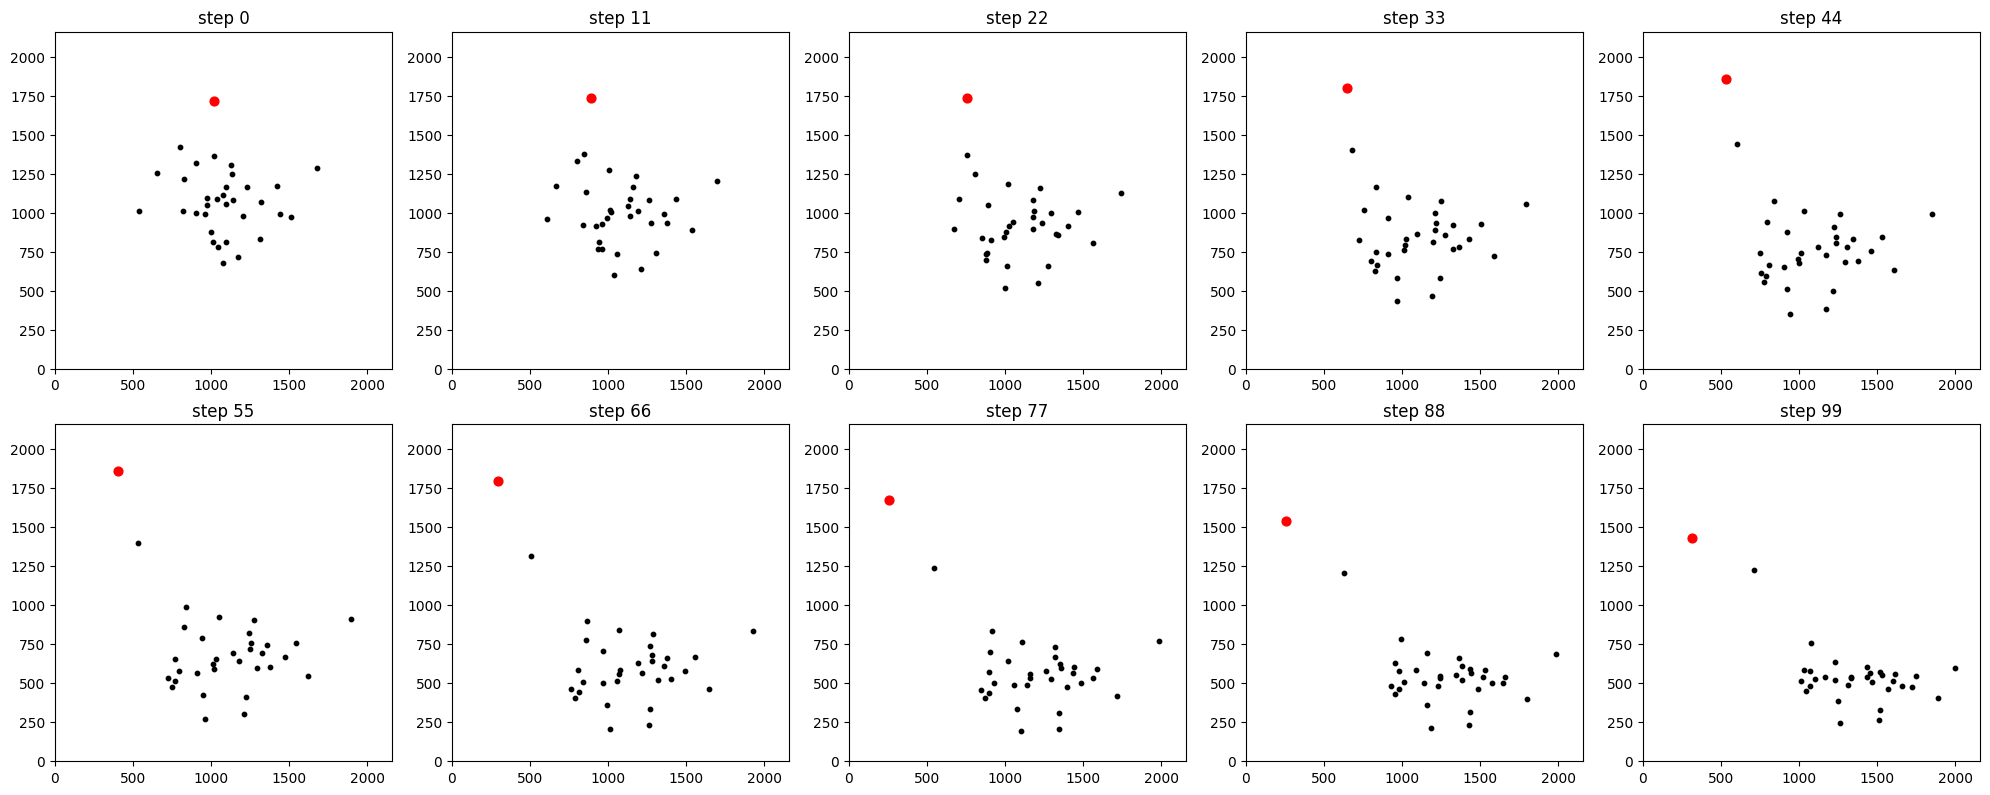

In [25]:
metrics_list_32, weights_list_32 = metrics_32
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = np.linspace(0, len(metrics_list_32) - 1, 10, dtype=int)
for ax, step in zip(axes.flat, steps_to_show):
    m = metrics_list_32[step]
    xs, ys = m["xs"] * 2160, m["ys"] * 2160
    ax.scatter(xs[1:], ys[1:], c='black', s=10, label='prey')
    ax.scatter(xs[0], ys[0], c='red', s=40, label='predator')
    ax.set_xlim(0, 2160); ax.set_ylim(0, 2160)
    ax.set_aspect('equal')
    ax.set_title(f"step {step}")
plt.tight_layout()
plt.show()

### Visualize BC (realistic speeds)

In [26]:
!apt-get install -y ffmpeg -qq

In [27]:
from pathlib import Path
import torch

# create the model structures
prey_policy = ModularPolicy(features=6).to(device)
pred_policy = ModularPolicy(features=5).to(device)

prey_path = Path("/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_prey_policy.pt")
pred_path = Path("/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_pred_policy.pt")

# load learned weights
prey_policy.load_state_dict(torch.load(prey_path, map_location=device, weights_only=True))
pred_policy.load_state_dict(torch.load(pred_path, map_location=device, weights_only=True))

# evaluation mode
prey_policy.eval()
pred_policy.eval()

print("Policies loaded successfully.")

Policies loaded successfully.


16 Prey Condition:

In [28]:
# load init pool
init_pool_path = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_16prey.pt')
init_pool = torch.load(init_pool_path).to(device)

In [29]:
%matplotlib inline
# run a simulation with the pretrained policies
gen_pred_tensor, gen_prey_tensor, metrics = run_env_simulation(visualization='off',
                                                      prey_policy=prey_policy, pred_policy=pred_policy,
                                                      n_prey=16, n_pred=1,
                                                      pred_speed=18, prey_speed=12,
                                                      max_speed_norm=25,
                                                      max_steps=100, step_size=1,
                                                      area_width=2160, area_height=2160,
                                                      max_turn=0.314,
                                                      init_pool=init_pool)
metrics_list, weights_list = metrics

In [30]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 2160)
ax.set_ylim(0, 2160)
ax.set_aspect("equal")

pred_scat = ax.scatter([], [], c="red", s=60, label="Predator")
prey_scat = ax.scatter([], [], c="blue", s=20, label="Prey")
ax.legend()

def update(frame):
    m = metrics_list[frame]

    xs = np.asarray(m["xs"]) * 2160
    ys = np.asarray(m["ys"]) * 2160

    pred_scat.set_offsets([[xs[0], ys[0]]])
    prey_scat.set_offsets(np.column_stack([xs[1:], ys[1:]]))

    ax.set_title(f"16 prey — step {frame}")
    return pred_scat, prey_scat

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(metrics_list),
    interval=1000 / 15,
    blit=True
)

out_path = "/content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_16prey_realistic_speeds.mp4"

ani.save(
    out_path,
    writer=animation.FFMpegWriter(fps=15, bitrate=1800)
)

plt.close(fig)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_16prey_realistic_speeds.mp4


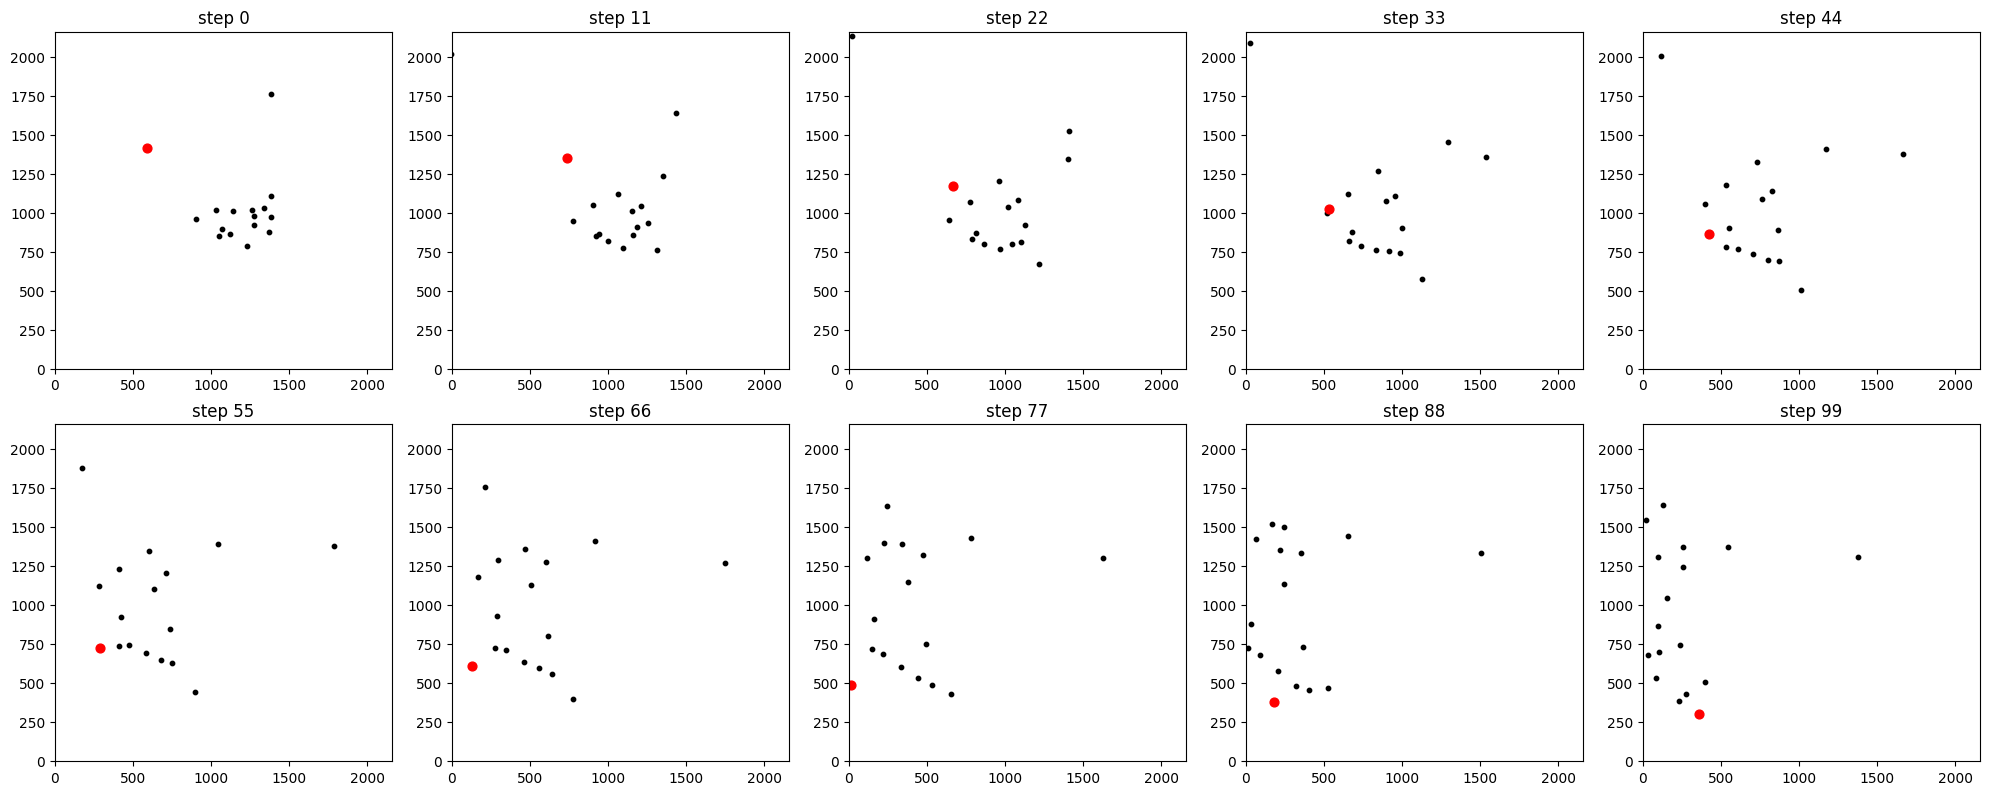

In [31]:
metrics_list, weights_list = metrics

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = np.linspace(0, len(metrics_list) - 1, 10, dtype=int)

for ax, step in zip(axes.flat, steps_to_show):
    m = metrics_list[step]
    xs, ys = m["xs"] * 2160, m["ys"] * 2160  # unscale back to pixel coords (area_width/height)
    ax.scatter(xs[1:], ys[1:], c='black', s=10, label='prey')
    ax.scatter(xs[0], ys[0], c='red', s=40, label='predator')
    ax.set_xlim(0, 2160); ax.set_ylim(0, 2160)
    ax.set_aspect('equal')
    ax.set_title(f"step {step}")
plt.tight_layout()
plt.show()

32 Prey Condition:

In [32]:
init_pool_32_path = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_32prey.pt')
init_pool_32 = torch.load(init_pool_32_path).to(device)

In [33]:
%matplotlib inline
# run a simulation with the pretrained policies — 32-prey condition
gen_pred_tensor_32, gen_prey_tensor_32, metrics_32 = run_env_simulation(visualization='off',
                                                      prey_policy=prey_policy, pred_policy=pred_policy,
                                                      n_prey=32, n_pred=1,
                                                      pred_speed=18, prey_speed=12,
                                                      max_speed_norm=25,
                                                      max_steps=100, step_size=1,
                                                      area_width=2160, area_height=2160,
                                                      max_turn=0.314,
                                                      init_pool=init_pool_32)
metrics_list_32, weights_list_32 = metrics_32

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 2160)
ax.set_ylim(0, 2160)
ax.set_aspect("equal")

pred_scat = ax.scatter([], [], c="red", s=60, label="Predator")
prey_scat = ax.scatter([], [], c="blue", s=20, label="Prey")
ax.legend()

def update(frame):
    m = metrics_list_32[frame]

    xs = np.asarray(m["xs"]) * 2160
    ys = np.asarray(m["ys"]) * 2160

    pred_scat.set_offsets([[xs[0], ys[0]]])
    prey_scat.set_offsets(np.column_stack([xs[1:], ys[1:]]))

    ax.set_title(f"32 prey — step {frame}")
    return pred_scat, prey_scat

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(metrics_list_32),
    interval=1000 / 15,
    blit=True
)

out_path_32 = "/content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_32prey_realistic_speeds.mp4"

ani.save(
    out_path_32,
    writer=animation.FFMpegWriter(fps=15, bitrate=1800)
)

plt.close(fig)
print("Saved:", out_path_32)

Saved: /content/drive/MyDrive/Predator Prey Thesis/BC Simulations/BC_simulation_32prey_realistic_speeds.mp4


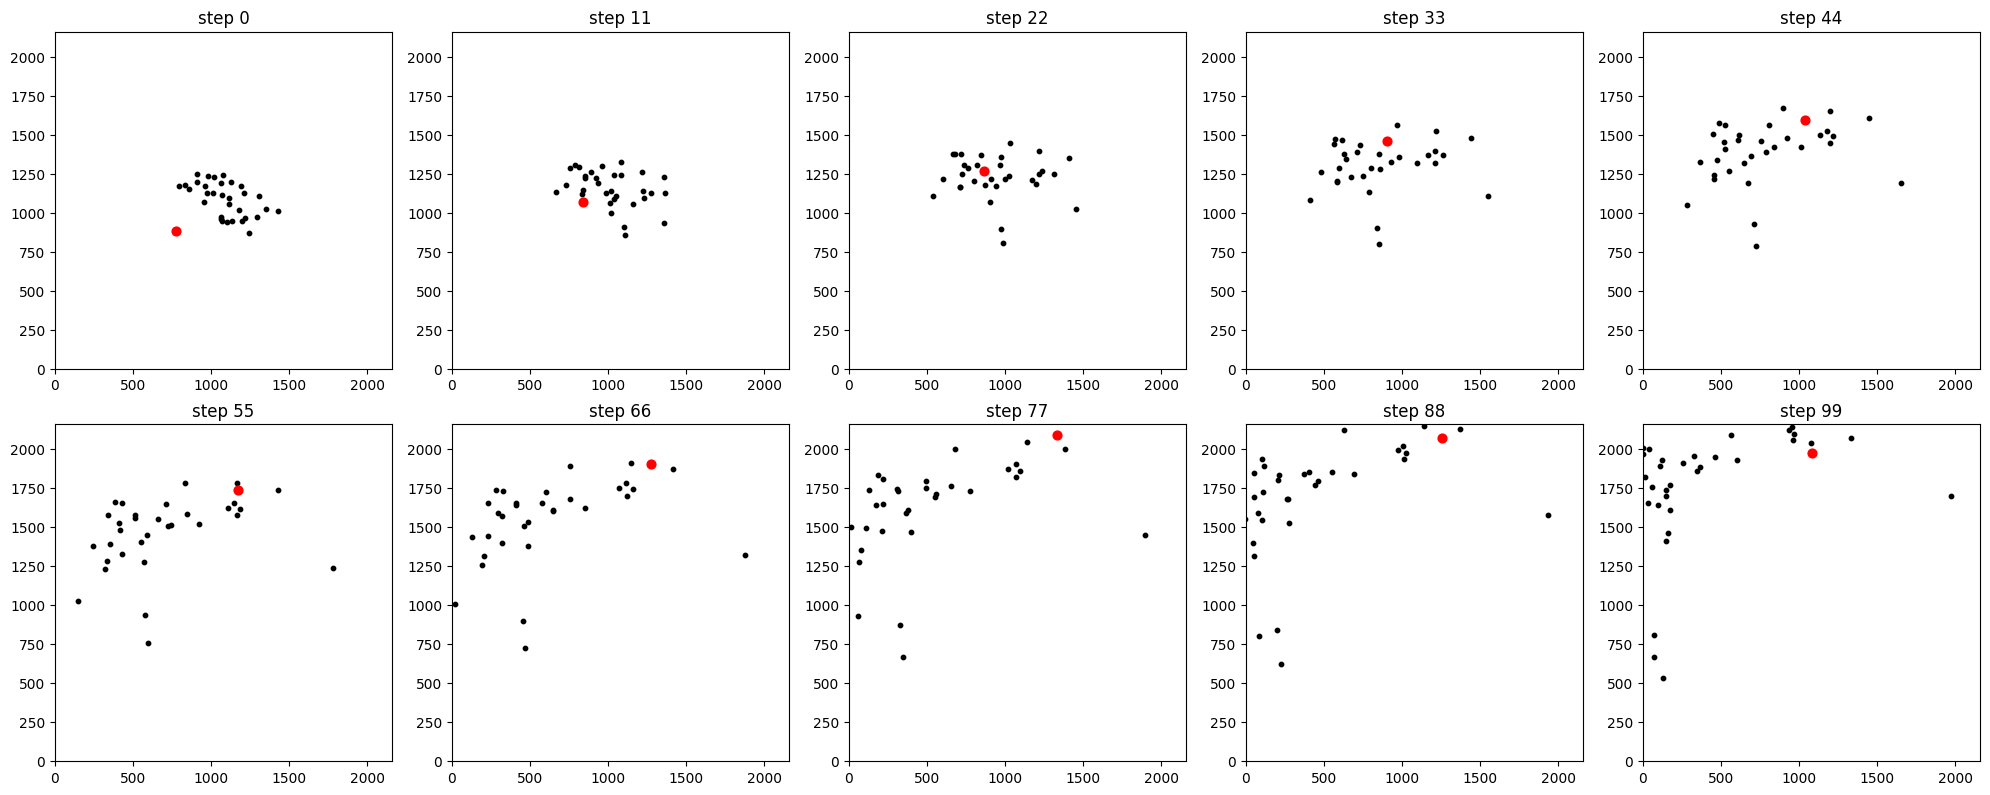

In [35]:
metrics_list_32, weights_list_32 = metrics_32
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = np.linspace(0, len(metrics_list_32) - 1, 10, dtype=int)
for ax, step in zip(axes.flat, steps_to_show):
    m = metrics_list_32[step]
    xs, ys = m["xs"] * 2160, m["ys"] * 2160
    ax.scatter(xs[1:], ys[1:], c='black', s=10, label='prey')
    ax.scatter(xs[0], ys[0], c='red', s=40, label='predator')
    ax.set_xlim(0, 2160); ax.set_ylim(0, 2160)
    ax.set_aspect('equal')
    ax.set_title(f"step {step}")
plt.tight_layout()
plt.show()